In [1]:
import os
import geopandas as gpd
import pandas as pd
import numpy as np
from pathlib import Path
from shapely.affinity import translate

os.chdir('../..')
print(f"Working directory: {os.getcwd()}")

UTM_CRS          = 32611   # UTM Zone 11N, metres — used for all geometry ops
NECK_THRESHOLD_M = 1.0     # erode by 1 m → severs necks narrower than ~2 m
MASTER           = "data/processed/assessor_lariac.gpkg"

from src.geoadmin import load_neighborhoods, load_cities, load_laraic

cities = load_cities().to_crs(4326)
hoods  = load_neighborhoods()
lacity = cities.query('CITYNAME_ALF == "LOS ANGELES"')

lacity_hood_names = set(
    gpd.sjoin(
        hoods.set_geometry(hoods.centroid.to_crs(4326)).set_crs(4326),
        lacity[['geometry']],
        predicate='intersects'
    )['name'].tolist()
)
print(f"{len(lacity_hood_names)} LA City neighborhoods")

Working directory: /Users/adamswietek/Documents/PostDoc/HiddenHousing
122 LA City neighborhoods


/var/folders/7b/rl6lkdns1dbfv_n3wwwmq8580000gn/T/ipykernel_44498/492099452.py:23: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  hoods.set_geometry(hoods.centroid.to_crs(4326)).set_crs(4326),


In [2]:
# ── params ────────────────────────────────────────────────────────────────────
STORE_SYMDIFF    = True   # True → also write added/removed geometry layers; False for production
SLIVER_BUFFER_M  = 0.4     # metres — border band width for sliver suppression

TEST_HOODS  = list(lacity_hood_names)#[:2]# for testing
EPOCH_PAIRS = [(2014, 2017), (2017, 2020)]

OUTPUT_PATH = "data/04_results/lariac_symdiff.gpkg"

In [3]:
import importlib
import src.symdiff
importlib.reload(src.symdiff)
from src.symdiff import lariac_epoch_diff


In [4]:
# Load parcel geometries from master (2017 layer — stable mid-period reference)
parcel_ref = (
    gpd.read_file(MASTER, layer='2017')[['AIN', 'geometry']]
    .assign(AIN=lambda d: d['AIN'].astype(str))
    .dropna(subset=['geometry'])
    .drop_duplicates('AIN')
    .reset_index(drop=True)
)
print(f"Parcel ref: {len(parcel_ref):,} parcels  CRS: {parcel_ref.crs}")

Parcel ref: 685,401 parcels  CRS: EPSG:2229


In [5]:
TRACT_PATH  = "data/03_processed/assessor_udu_tracts.gpkg"
EPOCH_PAIRS = [(2014, 2017), (2017, 2020)]

# ── AOI: pick one ─────────────────────────────────────────────────────────────

# Option A — single census tract
# tracts       = gpd.read_file(TRACT_PATH)
# sample_tract = tracts.sample(1, random_state=42)
# aoi_label    = sample_tract["GEOID_TRACT"].iloc[0]
# aoi          = sample_tract.to_crs(parcel_ref.crs)

# Option B — neighbourhood
aoi_label = "Boyle Heights"
aoi       = hoods[hoods["name"] == aoi_label].to_crs(parcel_ref.crs)

# ─────────────────────────────────────────────────────────────────────────────
print(f"AOI: {aoi_label}  |  bounds: {aoi.total_bounds.round(0)}")

tract_results = []
tract_out     = {}
for yr1, yr2 in EPOCH_PAIRS:
    o = lariac_epoch_diff(aoi, yr1, yr2, parcel_ref, label=aoi_label, store_geoms=True)
    tract_results.append(o["metrics"])
    tract_out[(yr1, yr2)] = o

tract_metrics = pd.concat(tract_results, ignore_index=True)

print(f"\nParcels processed per epoch:")
print(tract_metrics.groupby(["epoch", "change_type"]).size().unstack(fill_value=0).to_string())

AOI: Boyle Heights  |  bounds: [6491901. 1827040. 6503716. 1846359.]


/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/geopandas/io/file.py:521: UserWarning: More than one layer found in 'LARIAC4_Buildings_2014.gdb': 'LARIAC4_BUILDINGS_2014' (default), 'LARIAC2_BUILDINGS_DELETED_2014'. Specify layer parameter to avoid this warning.
  crs = pyogrio.read_info(path_or_bytes, layer=kwargs.get("layer")).get("crs")
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'LARIAC4_Buildings_2014.gdb': 'LARIAC4_BUILDINGS_2014' (default), 'LARIAC2_BUILDINGS_DELETED_2014'. Specify layer parameter to avoid this warning.
  result = read_func(
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/pyogrio/core.py:280: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiPolygon' is converted to 'MultiPolygon Z'
  return ogr_read_info(
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib


Parcels processed per epoch:
change_type  added_structure  demolished  extended  new_parcel  no_change  reduced  removed_structure
epoch                                                                                                
2014→2017                158         100       471          40       9219      221                226
2017→2020                137          53       308          23       9176      415                249


In [17]:
print("=== LARIAC buildings after AIN-switcher filter ===\n")

# n_{yr} columns hold per-AIN building counts from the dissolved footprint;
# summing gives total buildings that survived the filter for that year × epoch
for epoch, grp in tract_metrics.groupby("epoch"):
    yr1, yr2   = int(epoch[:4]), int(epoch[-4:])
    n_sw       = grp["n_switchers"].iloc[0]
    n_yr1      = int(grp[f"n_{yr1}"].sum())
    n_yr2      = int(grp[f"n_{yr2}"].sum())
    print(f"  {epoch}:")
    print(f"    {yr1}: {n_yr1:,} buildings used")
    print(f"    {yr2}: {n_yr2:,} buildings used")
    print(f"    {n_sw:,} buildings dropped as AIN switchers")

=== LARIAC buildings after AIN-switcher filter ===

  2014→2017:
    2014: 21,025 buildings used
    2017: 20,769 buildings used
    20 buildings dropped as AIN switchers
  2017→2020:
    2017: 20,778 buildings used
    2020: 20,601 buildings used
    13 buildings dropped as AIN switchers


In [27]:
from src.symdiff import drop_ain_switchers

aoi_union    = aoi.to_crs(parcel_ref.crs).union_all()
n_aoi_parcel = parcel_ref[parcel_ref.intersects(aoi_union)].shape[0]

# post-filter AIN counts from dissolved footprints
fp_ains = {
    2014: set(tract_out[(2014, 2017)]["footprints"][2014].index),
    2017: set(tract_out[(2014, 2017)]["footprints"][2017].index),
    2020: set(tract_out[(2017, 2020)]["footprints"][2020].index),
}

# switcher counts from pipeline metrics (consecutive epochs only)
sw = {ep: grp["n_switchers"].iloc[0]
      for ep, grp in tract_metrics.groupby("epoch")}

# ── table ────────────────────────────────────────────────────────────────────
cols   = ["Year", "AOI parcels", "LARIAC bldgs", "AINs w/ bldg",
          "Centroid AINs", "LARIAC src AINs", "↑ prev yr"]
widths = [6, 12, 13, 13, 14, 16, 10]
hdr    = "  ".join(f"{c:>{w}}" for c, w in zip(cols, widths))
print(hdr)
print("─" * len(hdr))

for yr in [2014, 2017, 2020]:
    lar = ain_frames[yr]
    cen = lar["centroid_AIN"].astype(str).str.strip().replace("nan", "")

    n_parcels_w_bldg = len(fp_ains[yr])
    n_centroid_ains  = cen[cen != ""].nunique()

    if "AIN" in lar.columns:
        src   = lar["AIN"].astype(str).str.strip().replace("nan", "")
        n_src = f"{src[src != ''].nunique():,}"
    else:
        n_src = "—"

    prev = ("—" if yr == 2014
            else f"{sw['2014→2017']:,}" if yr == 2017
            else f"{sw['2017→2020']:,}")

    vals = [yr, n_aoi_parcel, len(lar), n_parcels_w_bldg, n_centroid_ains, n_src, prev]
    print("  ".join(
        f"{str(v):>{w}}" if isinstance(v, str) else f"{v:>{w},}"
        for v, w in zip(vals, widths)
    ))

print()
print("AOI parcels     — parcel_ref rows intersecting the AOI (static 2017 reference)")
print("LARIAC bldgs    — raw building polygons in AOI (pre-filter)")
print("AINs w/ bldg    — unique AINs with ≥1 building after switcher filter")
print("Centroid AINs   — unique AINs from centroid sjoin (pre-filter)")
print("LARIAC src AINs — unique AINs from LARIAC's own field (2014 only)")
print("↑ prev yr       — buildings dropped: AIN changed vs prior survey (BLD_ID link)")


  Year   AOI parcels   LARIAC bldgs   AINs w/ bldg   Centroid AINs   LARIAC src AINs   ↑ prev yr
────────────────────────────────────────────────────────────────────────────────────────────────
 2,014        11,091         21,194         10,395          10,358            10,510           —
 2,017        11,091         20,966         10,335          10,339                 —          20
 2,020        11,091         20,799         10,308          10,309                 —          13

AOI parcels     — parcel_ref rows intersecting the AOI (static 2017 reference)
LARIAC bldgs    — raw building polygons in AOI (pre-filter)
AINs w/ bldg    — unique AINs with ≥1 building after switcher filter
Centroid AINs   — unique AINs from centroid sjoin (pre-filter)
LARIAC src AINs — unique AINs from LARIAC's own field (2014 only)
↑ prev yr       — buildings dropped: AIN changed vs prior survey (BLD_ID link)


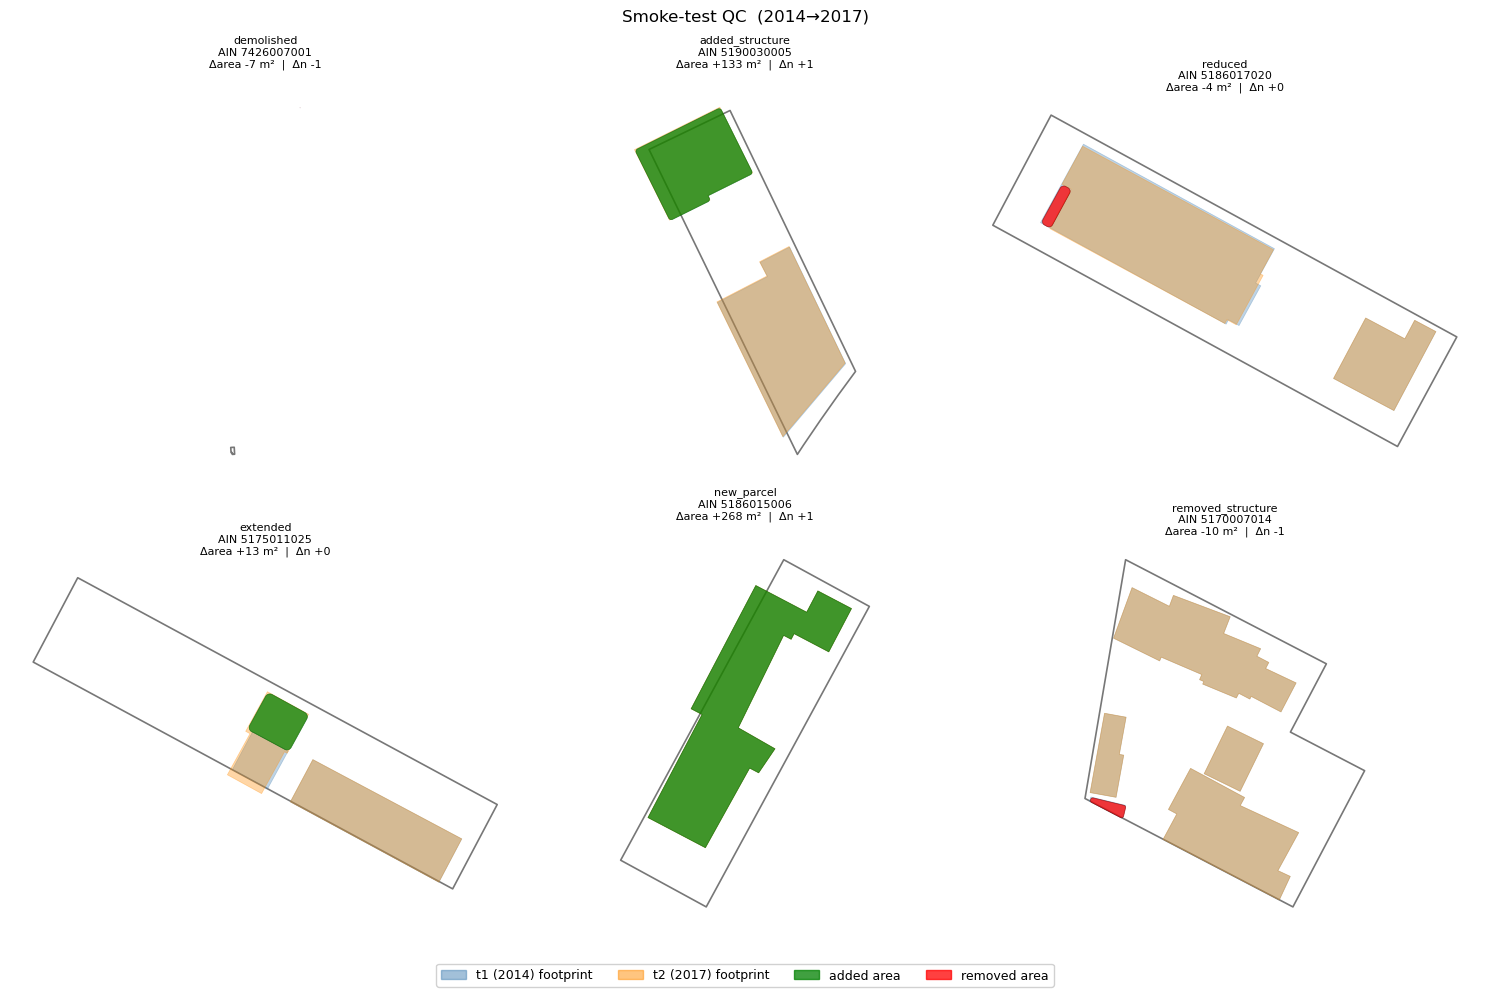

In [24]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

yr1, yr2 = 2014, 2017
o   = tract_out[(yr1, yr2)]
m   = o["metrics"]
fp1 = o["footprints"][yr1]
fp2 = o["footprints"][yr2]

added_lookup   = {r["AIN"]: r.geometry for _, r in o.get("added",   gpd.GeoDataFrame()).iterrows()}
removed_lookup = {r["AIN"]: r.geometry for _, r in o.get("removed", gpd.GeoDataFrame()).iterrows()}

change_types = [ct for ct in m["change_type"].unique() if ct != "no_change"]
n_cols = min(len(change_types), 3)
n_rows = -(-len(change_types) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

def _plot(ax, geom, crs, **kw):
    if geom is not None and not geom.is_empty:
        gpd.GeoSeries([geom], crs=crs).plot(ax=ax, **kw)

sign = lambda v: f"+{v:.0f}" if v >= 0 else f"{v:.0f}"

for ax, ct in zip(axes, change_types):
    cands = m[m["change_type"] == ct]
    if cands.empty:
        ax.set_title(f"{ct}\n(no examples)"); ax.axis("off"); continue

    row = cands.sample(1, random_state=42).iloc[0]
    ain = row["AIN"]
    crs = m.crs

    _plot(ax, row.geometry, crs, facecolor="none", edgecolor="#777", linewidth=1.2, zorder=1)
    if ain in fp1.index:
        _plot(ax, fp1.loc[ain, "footprint"], crs,
              facecolor="steelblue", edgecolor="steelblue", alpha=0.35, linewidth=0.5, zorder=2)
    if ain in fp2.index:
        _plot(ax, fp2.loc[ain, "footprint"], crs,
              facecolor="darkorange", edgecolor="darkorange", alpha=0.35, linewidth=0.5, zorder=2)
    _plot(ax, added_lookup.get(ain),   crs, color="green", alpha=0.75, edgecolor="darkgreen", linewidth=0.5, zorder=3)
    _plot(ax, removed_lookup.get(ain), crs, color="red",   alpha=0.75, edgecolor="darkred",   linewidth=0.5, zorder=3)

    ax.set_title(f"{ct}\nAIN {ain}\nΔarea {sign(row['area_net'])} m²  |  Δn {sign(row['n_delta'])}", fontsize=8)
    ax.axis("off")

for ax in axes[len(change_types):]:
    ax.axis("off")

legend = [
    mpatches.Patch(color="steelblue",  alpha=0.5, label=f"t1 ({yr1}) footprint"),
    mpatches.Patch(color="darkorange", alpha=0.5, label=f"t2 ({yr2}) footprint"),
    mpatches.Patch(color="green",      alpha=0.75, label="added area"),
    mpatches.Patch(color="red",        alpha=0.75, label="removed area"),
]
fig.legend(handles=legend, loc="lower center", ncol=4, fontsize=9, framealpha=0.9)
plt.suptitle(f"Smoke-test QC  ({yr1}→{yr2})", fontsize=12)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

## Cross-epoch comparison

In [26]:
SQM_TO_SQFT = 10.764
epoch1, epoch2 = "2014→2017", "2017→2020"
changed = tract_metrics[tract_metrics["change_type"] != "no_change"]

# ── 1. Parcel overlap ─────────────────────────────────────────────────────────
ains_e1 = set(changed[changed["epoch"] == epoch1]["AIN"])
ains_e2 = set(changed[changed["epoch"] == epoch2]["AIN"])
total   = tract_metrics["AIN"].nunique()

overlap = {
    f"{epoch1} only": len(ains_e1 - ains_e2),
    "Both epochs":    len(ains_e1 & ains_e2),
    f"{epoch2} only": len(ains_e2 - ains_e1),
    "Either epoch":   len(ains_e1 | ains_e2),
}
print(f"Total unique parcels in tract: {total}\n")
print("Parcels with any structural change:")
for k, n in overlap.items():
    print(f"  {k:<20}  {n:>3}  ({n/total:5.1%})")

# ── 2. Share by change type × epoch ──────────────────────────────────────────
ct_n = (
    tract_metrics
    .groupby(["epoch", "change_type"]).size()
    .unstack("change_type", fill_value=0)
)
ct_pct = ct_n.div(ct_n.sum(axis=1), axis=0) * 100

print(f"\nShare of parcels by change type (%):")
print(ct_pct.drop(columns="no_change", errors="ignore").round(1).to_string())

# ── 3. Mean sqft net change by change type × epoch ───────────────────────────
area_stats = (
    changed
    .assign(area_net_sqft=lambda d: d["area_net"] * SQM_TO_SQFT)
    .groupby(["epoch", "change_type"])["area_net_sqft"]
    .agg(mean="mean", median="median", n="count")
    .round(0)
)
print(f"\nMean net area (sqft) by change type and epoch:")
print(area_stats.to_string())

Total unique parcels in tract: 10457

Parcels with any structural change:
  2014→2017 only        1030  ( 9.8%)
  Both epochs           186  ( 1.8%)
  2017→2020 only        999  ( 9.6%)
  Either epoch          2215  (21.2%)

Share of parcels by change type (%):
change_type  added_structure  demolished  extended  new_parcel  reduced  removed_structure
epoch                                                                                     
2014→2017                1.5         1.0       4.5         0.4      2.1                2.2
2017→2020                1.3         0.5       3.0         0.2      4.0                2.4

Mean net area (sqft) by change type and epoch:
                                mean  median    n
epoch     change_type                            
2014→2017 added_structure     1009.0   490.0  158
          demolished         -7593.0 -1722.0  100
          extended             448.0   240.0  471
          new_parcel         11690.0  3007.0   40
          reduced         

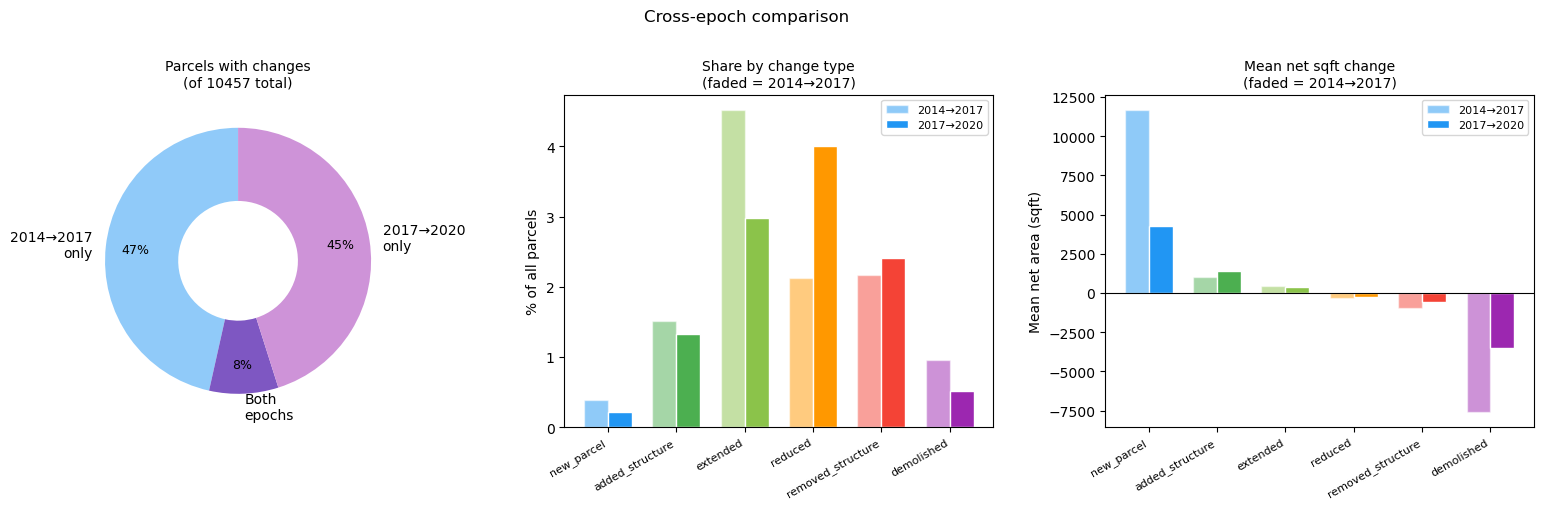

In [28]:
import matplotlib.pyplot as plt
import numpy as np

CHANGE_ORDER = ["new_parcel", "added_structure", "extended",
                "reduced", "removed_structure", "demolished"]
COLORS = {
    "new_parcel":        "#2196F3",
    "added_structure":   "#4CAF50",
    "extended":          "#8BC34A",
    "reduced":           "#FF9800",
    "removed_structure": "#F44336",
    "demolished":        "#9C27B0",
}
present = [c for c in CHANGE_ORDER if c in ct_pct.columns]
epochs  = [epoch1, epoch2]
x, w    = np.arange(len(present)), 0.35

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── panel 1: parcel overlap donut ────────────────────────────────────────────
ax = axes[0]
vals   = [overlap[epoch1 + " only"], overlap["Both epochs"], overlap[epoch2 + " only"]]
labels = [f"{epoch1}\nonly", "Both\nepochs", f"{epoch2}\nonly"]
wedges, _, autotexts = ax.pie(
    vals, labels=labels, colors=["#90CAF9", "#7E57C2", "#CE93D8"],
    autopct=lambda p: f"{p:.0f}%" if p > 0 else "",
    startangle=90, wedgeprops={"width": 0.55}, pctdistance=0.78,
)
for t in autotexts:
    t.set_fontsize(9)
ax.set_title(f"Parcels with changes\n(of {total} total)", fontsize=10)

# ── panel 2: % share by change type × epoch ──────────────────────────────────
ax = axes[1]
for i, (ep, off, alpha) in enumerate(zip(epochs, [-w/2, w/2], [0.5, 1.0])):
    vals = [ct_pct.loc[ep, c] if c in ct_pct.columns else 0 for c in present]
    ax.bar(x + off, vals, w, label=ep,
           color=[COLORS[c] for c in present], alpha=alpha, edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(present, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("% of all parcels")
ax.set_title("Share by change type\n(faded = 2014→2017)", fontsize=10)
ax.legend(fontsize=8)

# ── panel 3: mean sqft net change × epoch ────────────────────────────────────
ax = axes[2]
for i, (ep, off, alpha) in enumerate(zip(epochs, [-w/2, w/2], [0.5, 1.0])):
    if ep not in area_stats.index.get_level_values("epoch"):
        continue
    sub  = area_stats.loc[ep]["mean"]
    vals = [sub.get(c, 0) if hasattr(sub, "get") else (sub[c] if c in sub.index else 0)
            for c in present]
    ax.bar(x + off, vals, w, label=ep,
           color=[COLORS[c] for c in present], alpha=alpha, edgecolor="white")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(present, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("Mean net area (sqft)")
ax.set_title("Mean net sqft change\n(faded = 2014→2017)", fontsize=10)
ax.legend(fontsize=8)

plt.suptitle(f"Cross-epoch comparison ", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## AIN building assignment — neighbourhood context

## AIN assignment stability across LARIAC vintages

In [14]:
from src.symdiff import _load_lariac, UTM_CRS

YEARS = [2014, 2017, 2020]

# ── 1. load raw LARIAC buildings for current AOI ──────────────────────────
raw = {}
for yr in YEARS:
    lar = _load_lariac(aoi, yr)
    raw[yr] = lar[lar["CODE"] == "Building"].copy().to_crs(parcel_ref.crs)

# ── 2. centroid-AIN assignment (renamed column to avoid sjoin conflict) ───
parcel_lkp = parcel_ref[["AIN", "geometry"]].rename(columns={"AIN": "parcel_AIN"})

def assign_centroid_ain(lar, lkp):
    cents  = lar.copy().set_geometry(lar.centroid)
    joined = gpd.sjoin(cents, lkp, how="left")
    joined = joined[~joined.index.duplicated(keep="first")]
    return joined["parcel_AIN"].values

# ── 3. agreement: LARIAC built-in AIN field vs centroid-sjoin AIN ─────────
print("=== LARIAC built-in AIN vs centroid-sjoin ===\n")
ain_frames = {}
for yr in YEARS:
    lar = raw[yr].copy()
    lar["centroid_AIN"] = assign_centroid_ain(lar, parcel_lkp)
    ain_frames[yr] = lar

    n = len(lar)
    if "AIN" in lar.columns:
        src  = lar["AIN"].astype(str).str.strip().replace("nan", "")
        cen  = lar["centroid_AIN"].astype(str).str.strip().replace("nan", "")
        both = (src != "") & (cen != "")
        agr  = (src[both] == cen[both]).mean() if both.any() else float("nan")
        n_src = (src != "").sum()
        n_cen = (cen != "").sum()
        print(f"  {yr}  n_bldgs={n:,}  "
              f"src-AIN filled={n_src:,} ({n_src/n:.0%})  "
              f"centroid-AIN filled={n_cen:,} ({n_cen/n:.0%})  "
              f"agreement={agr:.1%}")
    else:
        print(f"  {yr}  n_bldgs={n:,}  (no built-in AIN field)")

# ── 4. cross-vintage AIN stability via nearest-centroid match ─────────────
MATCH_M = 5.0   # buildings whose centroids are ≤5 m apart are the same structure

def vintage_stability(yr_a, yr_b):
    def to_utm_cents(yr):
        gdf = ain_frames[yr].to_crs(UTM_CRS)
        return (gdf
                .set_geometry(gdf.centroid)
                [["geometry", "centroid_AIN"]]
                .rename(columns={"centroid_AIN": f"ain_{yr}"}))

    a = to_utm_cents(yr_a)
    b = to_utm_cents(yr_b)
    matched = gpd.sjoin_nearest(a, b, how="inner", max_distance=MATCH_M, distance_col="d")
    matched = matched[~matched.index.duplicated(keep="first")]

    ca = matched[f"ain_{yr_a}"].astype(str).str.strip().replace("nan", "")
    cb = matched[f"ain_{yr_b}"].astype(str).str.strip().replace("nan", "")
    valid  = (ca != "") & (cb != "")
    stable = (ca[valid] == cb[valid]).mean() if valid.any() else float("nan")
    return len(matched), valid.sum(), stable

print(f"\n=== Cross-vintage AIN stability (nearest-centroid ≤ {MATCH_M} m) ===\n")
for yr_a, yr_b in [(2014, 2017), (2017, 2020), (2014, 2020)]:
    n_match, n_valid, stab = vintage_stability(yr_a, yr_b)
    print(f"  {yr_a}→{yr_b}:  {n_match:,} matched,  "
          f"{n_valid:,} with valid AIN both sides,  "
          f"AIN-stable={stab:.1%},  switched={1-stab:.1%}")

/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/geopandas/io/file.py:521: UserWarning: More than one layer found in 'LARIAC4_Buildings_2014.gdb': 'LARIAC4_BUILDINGS_2014' (default), 'LARIAC2_BUILDINGS_DELETED_2014'. Specify layer parameter to avoid this warning.
  crs = pyogrio.read_info(path_or_bytes, layer=kwargs.get("layer")).get("crs")
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'LARIAC4_Buildings_2014.gdb': 'LARIAC4_BUILDINGS_2014' (default), 'LARIAC2_BUILDINGS_DELETED_2014'. Specify layer parameter to avoid this warning.
  result = read_func(
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/pyogrio/core.py:280: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiPolygon' is converted to 'MultiPolygon Z'
  return ogr_read_info(
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib

=== LARIAC built-in AIN vs centroid-sjoin ===

  2014  n_bldgs=21,194  src-AIN filled=21,191 (100%)  centroid-AIN filled=21,194 (100%)  agreement=96.2%
  2017  n_bldgs=20,966  (no built-in AIN field)
  2020  n_bldgs=20,799  (no built-in AIN field)

=== Cross-vintage AIN stability (nearest-centroid ≤ 5.0 m) ===

  2014→2017:  20,748 matched,  20,748 with valid AIN both sides,  AIN-stable=98.2%,  switched=1.8%
  2017→2020:  20,486 matched,  20,486 with valid AIN both sides,  AIN-stable=98.7%,  switched=1.3%
  2014→2020:  20,297 matched,  20,297 with valid AIN both sides,  AIN-stable=98.2%,  switched=1.8%


371 buildings switched AIN between 2014 and 2017


/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/geopandas/io/file.py:521: UserWarning: More than one layer found in 'LARIAC4_Buildings_2014.gdb': 'LARIAC4_BUILDINGS_2014' (default), 'LARIAC2_BUILDINGS_DELETED_2014'. Specify layer parameter to avoid this warning.
  crs = pyogrio.read_info(path_or_bytes, layer=kwargs.get("layer")).get("crs")
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'LARIAC4_Buildings_2014.gdb': 'LARIAC4_BUILDINGS_2014' (default), 'LARIAC2_BUILDINGS_DELETED_2014'. Specify layer parameter to avoid this warning.
  result = read_func(
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/pyogrio/core.py:280: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiPolygon' is converted to 'MultiPolygon Z'
  return ogr_read_info(
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib

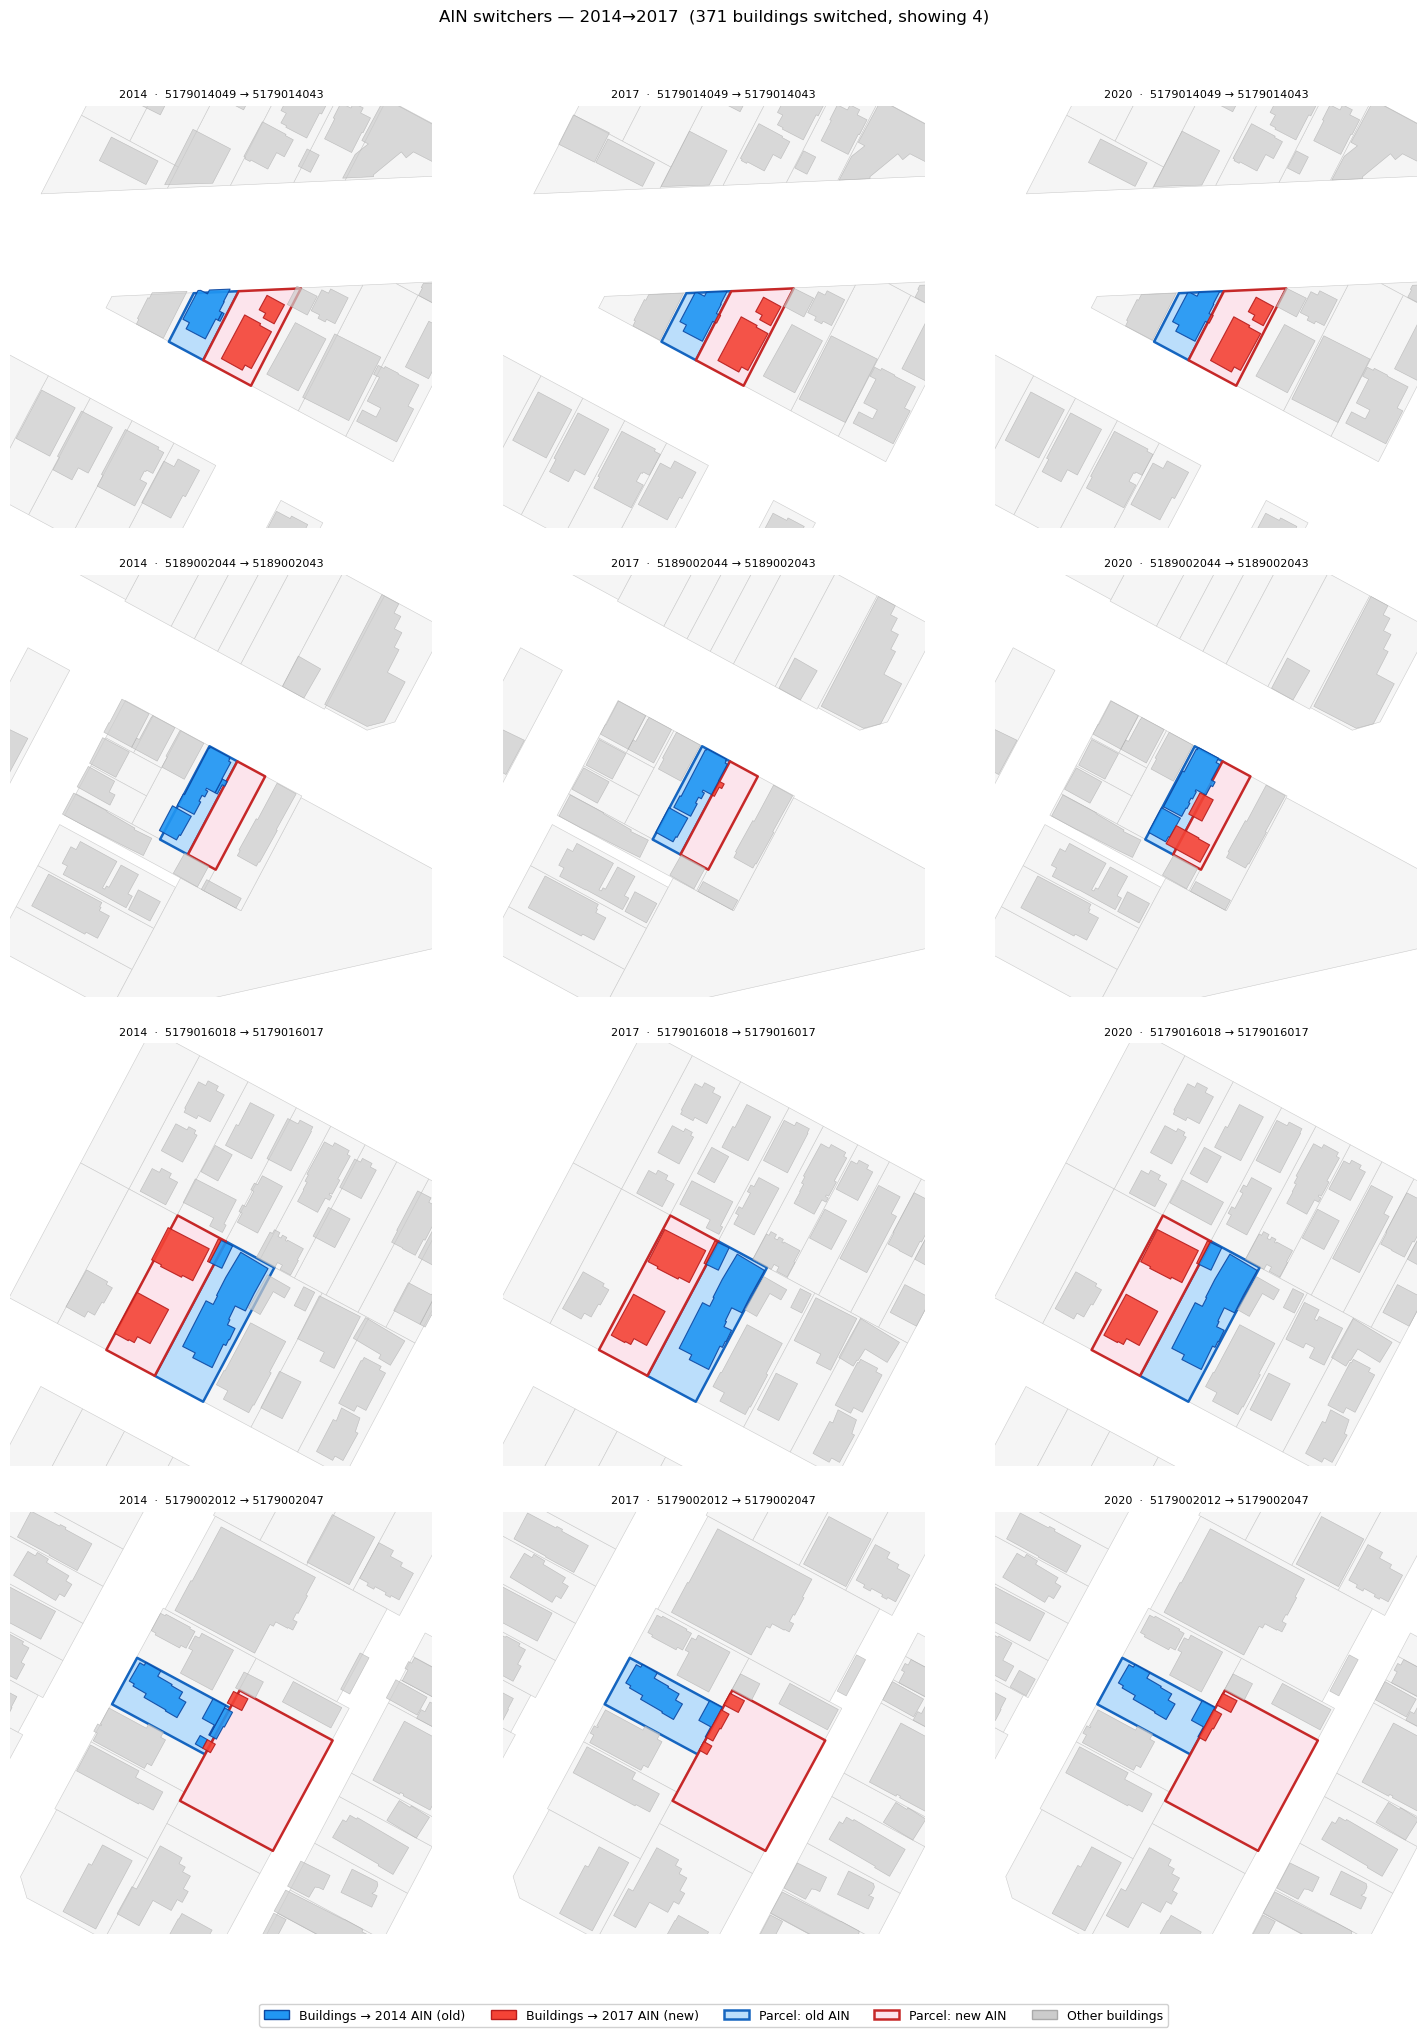

In [31]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

N_EXAMPLES = 4
BUFFER_FT  = 200
PAIR       = (2014, 2017)   # epoch to sample switchers from

yr_a, yr_b = PAIR

# ── re-match buildings across vintages to find AIN switchers ─────────────
def to_utm_cents_idx(yr):
    gdf = ain_frames[yr].to_crs(UTM_CRS)
    return (gdf
            .set_geometry(gdf.centroid)
            [["geometry", "centroid_AIN"]]
            .rename(columns={"centroid_AIN": f"ain_{yr}"}))

a = to_utm_cents_idx(yr_a)
b = to_utm_cents_idx(yr_b)
matched = gpd.sjoin_nearest(a, b, how="inner", max_distance=5.0, distance_col="d")
matched = matched[~matched.index.duplicated(keep="first")]

ca = matched[f"ain_{yr_a}"].astype(str).str.strip().replace("nan", "")
cb = matched[f"ain_{yr_b}"].astype(str).str.strip().replace("nan", "")
switched = (ca != "") & (cb != "") & (ca != cb)

switchers           = matched[switched].copy()
switchers["ain_a"]  = ca[switched].values
switchers["ain_b"]  = cb[switched].values
# recover building polygon in parcel_ref CRS (index preserved from ain_frames)
switchers["bldg_geom"] = ain_frames[yr_a].to_crs(parcel_ref.crs).geometry.loc[switchers.index].values

print(f"{len(switchers)} buildings switched AIN between {yr_a} and {yr_b}")
sample = switchers.sample(min(N_EXAMPLES, len(switchers)), random_state=7)

# ── plot: N rows × 3 years ───────────────────────────────────────────────
fig, axes = plt.subplots(len(sample), 3, figsize=(15, 5 * len(sample)), squeeze=False)

for row_i, (_, sw) in enumerate(sample.iterrows()):
    ain_old, ain_new = sw["ain_a"], sw["ain_b"]
    p_old = parcel_ref[parcel_ref["AIN"] == ain_old]
    p_new = parcel_ref[parcel_ref["AIN"] == ain_new]

    center   = sw["bldg_geom"].centroid
    buf_geom = center.buffer(BUFFER_FT)
    buf_gdf  = gpd.GeoDataFrame(geometry=[buf_geom], crs=parcel_ref.crs)
    neighbors = parcel_ref[parcel_ref.intersects(buf_geom)]
    x0, y0, x1, y1 = buf_geom.bounds

    for col_j, yr in enumerate(YEARS):
        ax = axes[row_i][col_j]

        lar = _load_lariac(buf_gdf, yr)
        lar = lar[lar["CODE"] == "Building"].to_crs(parcel_ref.crs).copy()

        if not lar.empty:
            cents  = lar.set_geometry(lar.centroid)
            joined = gpd.sjoin(cents, parcel_lkp, how="left")
            joined = joined[~joined.index.duplicated(keep="first")]
            lar["assigned_AIN"] = joined["parcel_AIN"].values

        # parcel backgrounds
        neighbors.plot(ax=ax, facecolor="#f5f5f5", edgecolor="#ccc", linewidth=0.4, zorder=1)
        if not p_old.empty:
            p_old.plot(ax=ax, facecolor="#BBDEFB", edgecolor="#1565C0", linewidth=1.8, zorder=2)
        if not p_new.empty:
            p_new.plot(ax=ax, facecolor="#FCE4EC", edgecolor="#C62828", linewidth=1.8, zorder=2)

        if not lar.empty:
            m_old   = lar[lar["assigned_AIN"] == ain_old]
            m_new   = lar[lar["assigned_AIN"] == ain_new]
            m_other = lar[~lar["assigned_AIN"].isin([ain_old, ain_new])]
            if not m_other.empty:
                m_other.plot(ax=ax, facecolor="#ccc", edgecolor="#aaa", linewidth=0.4, alpha=0.7, zorder=3)
            if not m_old.empty:
                m_old.plot(ax=ax, facecolor="#2196F3", edgecolor="#0D47A1", linewidth=0.8, alpha=0.9, zorder=4)
            if not m_new.empty:
                m_new.plot(ax=ax, facecolor="#F44336", edgecolor="#B71C1C", linewidth=0.8, alpha=0.9, zorder=4)

        ax.set_xlim(x0, x1); ax.set_ylim(y0, y1)
        ax.set_title(f"{yr}  ·  {ain_old} → {ain_new}", fontsize=8)
        ax.axis("off")

legend = [
    mpatches.Patch(facecolor="#2196F3", edgecolor="#0D47A1", label=f"Buildings → {yr_a} AIN (old)"),
    mpatches.Patch(facecolor="#F44336", edgecolor="#B71C1C", label=f"Buildings → {yr_b} AIN (new)"),
    mpatches.Patch(facecolor="#BBDEFB", edgecolor="#1565C0", linewidth=1.8, label=f"Parcel: old AIN"),
    mpatches.Patch(facecolor="#FCE4EC", edgecolor="#C62828", linewidth=1.8, label=f"Parcel: new AIN"),
    mpatches.Patch(facecolor="#ccc",    edgecolor="#aaa",    label="Other buildings"),
]
fig.legend(handles=legend, loc="lower center", ncol=5, fontsize=9, framealpha=0.9)
plt.suptitle(f"AIN switchers — {yr_a}→{yr_b}  ({len(switchers)} buildings switched, showing {len(sample)})",
             fontsize=12, y=1.01)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

2014 has BLD_ID: True  |  2017 has OLD_BLD_ID: True
2017 OLD_BLD_ID filled: 20,966 of 20,966

973 buildings linked via OLD_BLD_ID  →  16 AIN switchers


/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/geopandas/io/file.py:521: UserWarning: More than one layer found in 'LARIAC4_Buildings_2014.gdb': 'LARIAC4_BUILDINGS_2014' (default), 'LARIAC2_BUILDINGS_DELETED_2014'. Specify layer parameter to avoid this warning.
  crs = pyogrio.read_info(path_or_bytes, layer=kwargs.get("layer")).get("crs")
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'LARIAC4_Buildings_2014.gdb': 'LARIAC4_BUILDINGS_2014' (default), 'LARIAC2_BUILDINGS_DELETED_2014'. Specify layer parameter to avoid this warning.
  result = read_func(
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/pyogrio/core.py:280: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiPolygon' is converted to 'MultiPolygon Z'
  return ogr_read_info(
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib

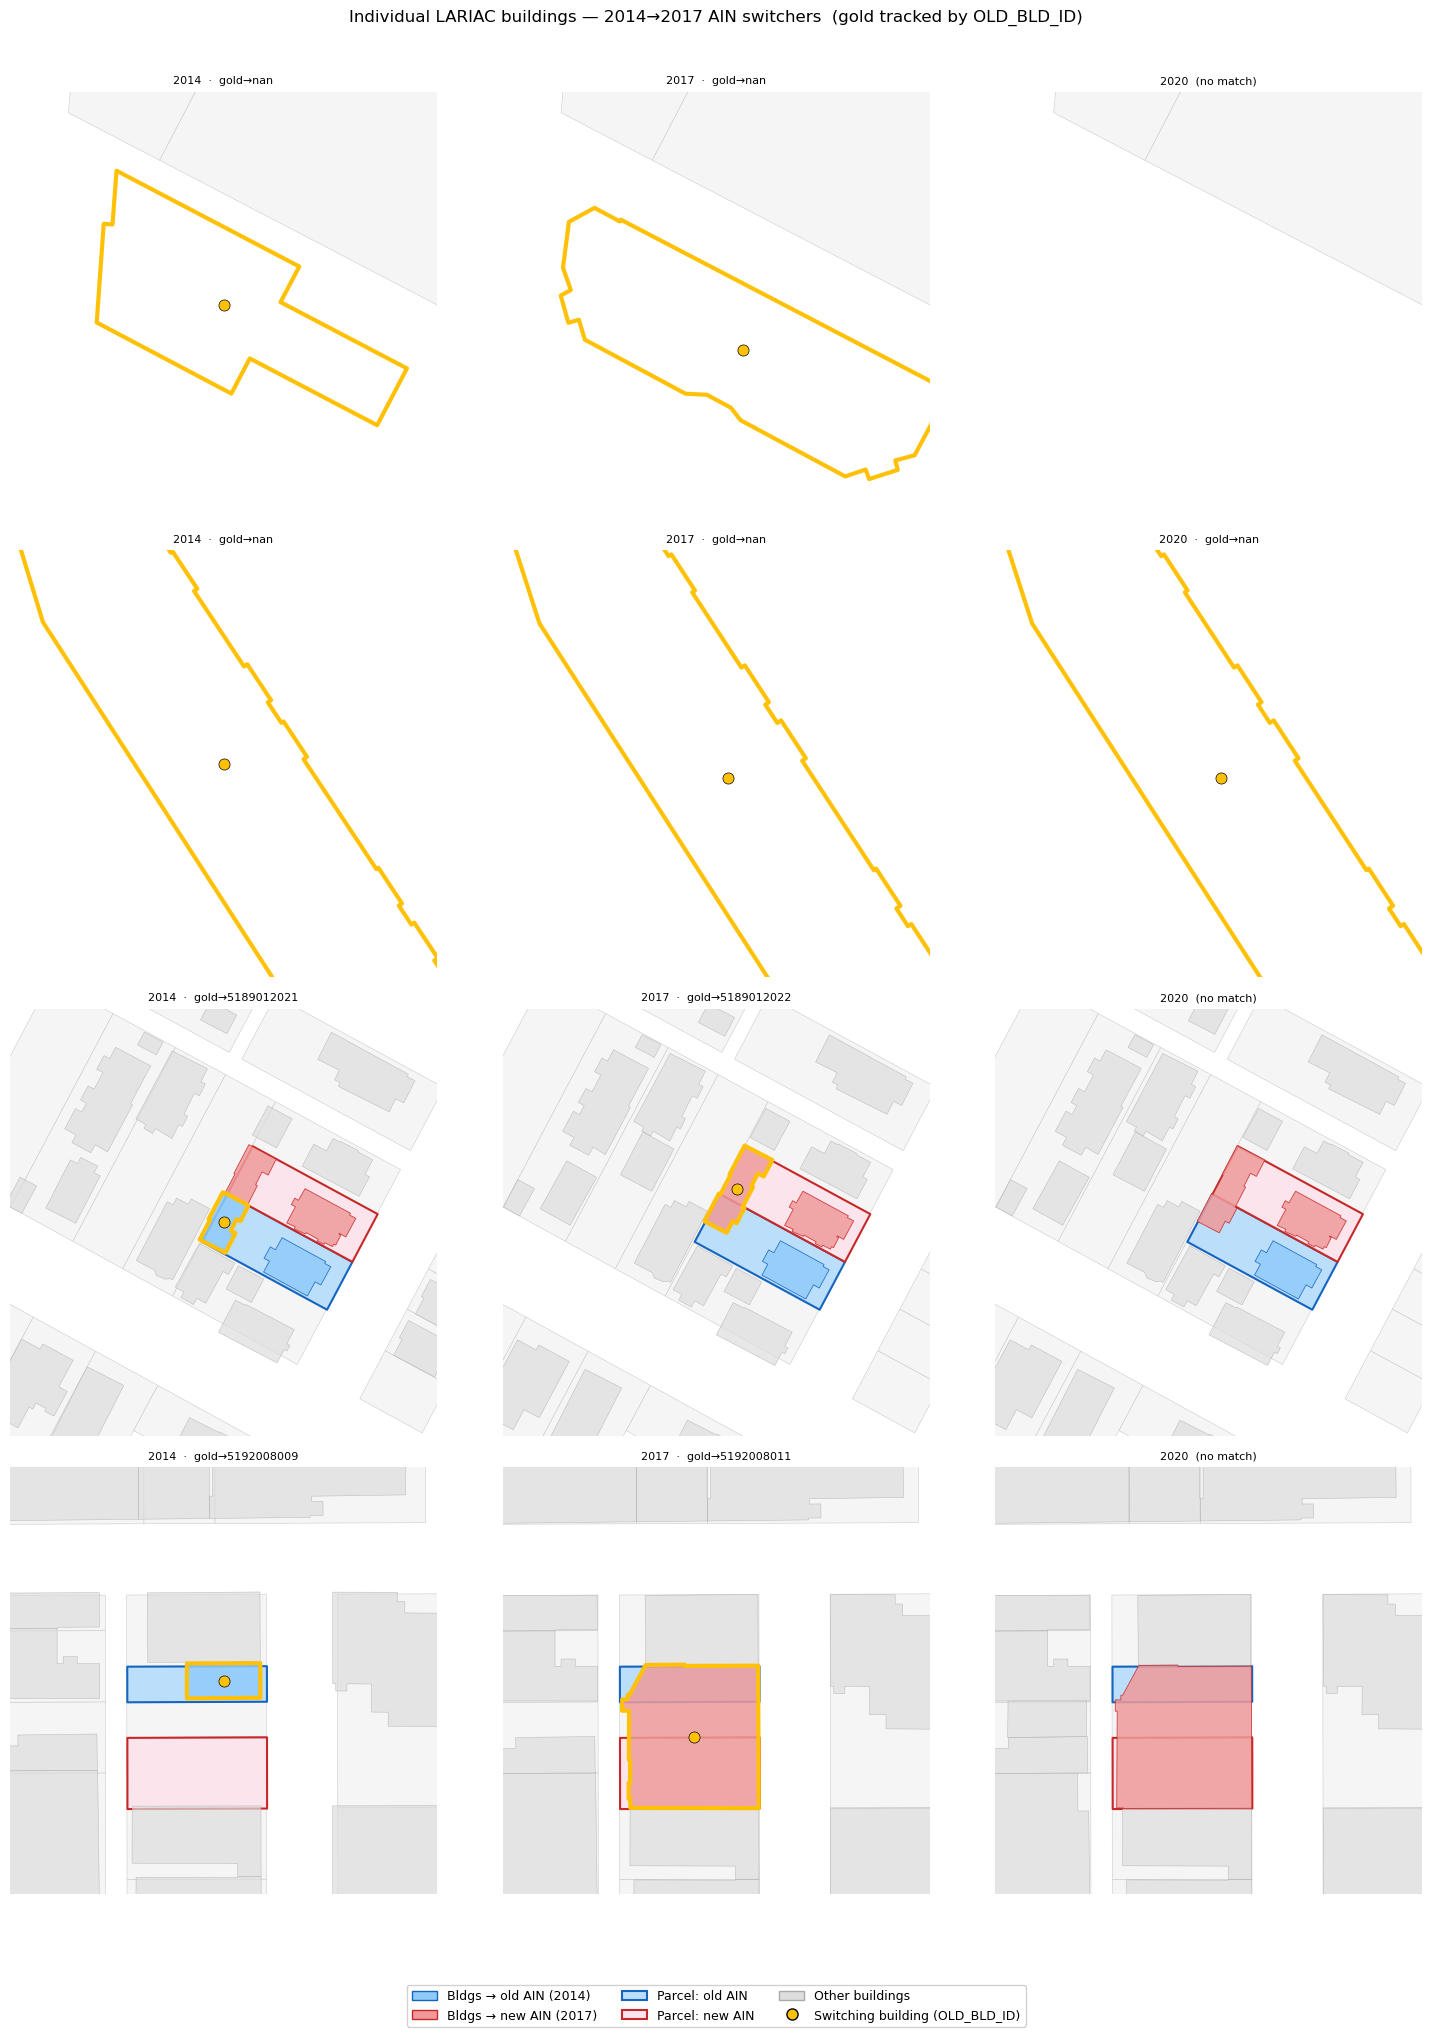

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── BLD_ID availability check ─────────────────────────────────────────────
has_bldid_14  = "BLD_ID"     in ain_frames[2014].columns
has_oldbld_17 = "OLD_BLD_ID" in ain_frames[2017].columns
print(f"2014 has BLD_ID: {has_bldid_14}  |  2017 has OLD_BLD_ID: {has_oldbld_17}")
print(f"2017 OLD_BLD_ID filled: {ain_frames[2017]['OLD_BLD_ID'].astype(str).str.strip().replace('nan','').ne('').sum():,} "
      f"of {len(ain_frames[2017]):,}") if has_oldbld_17 else None

# ── find 2014↔2017 switchers via OLD_BLD_ID (definitive structural link) ─
N_EXAMPLES = 4
BUFFER_FT  = 150

if has_bldid_14 and has_oldbld_17:
    # build 2014 BLD_ID → (df-index, centroid_AIN) lookup
    bld14 = ain_frames[2014][["BLD_ID", "centroid_AIN"]].copy()
    bld14["BLD_ID"] = bld14["BLD_ID"].astype(str).str.strip().replace("nan", "")
    bld14 = bld14[bld14["BLD_ID"] != ""].reset_index().rename(columns={"index": "idx_a"})
    bld14_by_id = bld14.set_index("BLD_ID")

    # 2017 buildings that reference a 2014 structure
    bld17 = ain_frames[2017][["OLD_BLD_ID", "centroid_AIN"]].copy()
    bld17["OLD_BLD_ID"] = bld17["OLD_BLD_ID"].astype(str).str.strip().replace("nan", "")
    bld17 = bld17[bld17["OLD_BLD_ID"] != ""].reset_index().rename(columns={"index": "idx_b"})

    merged = bld17.merge(
        bld14_by_id[["idx_a", "centroid_AIN"]].rename(columns={"centroid_AIN": "ain_2014"}),
        left_on="OLD_BLD_ID", right_index=True, how="inner",
    ).rename(columns={"centroid_AIN": "ain_2017"})

    ca = merged["ain_2014"].astype(str).str.strip().replace("nan", "")
    cb = merged["ain_2017"].astype(str).str.strip().replace("nan", "")
    switched = (ca != "") & (cb != "") & (ca != cb)

    switchers_id = merged[switched].copy()
    switchers_id["ain_old"] = ca[switched].values
    switchers_id["ain_new"] = cb[switched].values
    print(f"\n{len(merged):,} buildings linked via OLD_BLD_ID  →  {len(switchers_id)} AIN switchers")
    match_method = "OLD_BLD_ID"
else:
    # fallback: centroid proximity
    def to_utm_cents_idx(yr):
        gdf = ain_frames[yr].to_crs(UTM_CRS)
        return gdf.set_geometry(gdf.centroid)[["geometry","centroid_AIN"]].rename(
            columns={"centroid_AIN": f"ain_{yr}"})
    a = to_utm_cents_idx(2014); b = to_utm_cents_idx(2017)
    m = gpd.sjoin_nearest(a, b, how="inner", max_distance=5.0, distance_col="d")
    m = m[~m.index.duplicated(keep="first")]
    ca = m["ain_2014"].astype(str).str.strip().replace("nan","")
    cb = m["ain_2017"].astype(str).str.strip().replace("nan","")
    switched = (ca!="") & (cb!="") & (ca!=cb)
    switchers_id = m[switched].copy()
    switchers_id["ain_old"] = ca[switched].values
    switchers_id["ain_new"] = cb[switched].values
    switchers_id["idx_a"] = switchers_id.index
    switchers_id["idx_b"] = switchers_id["index_right"]
    match_method = "centroid-proximity"
    print(f"{len(switchers_id)} switchers (fallback: {match_method})")

sample = switchers_id.sample(min(N_EXAMPLES, len(switchers_id)), random_state=7)

# ── 2020 UTM centroids for nearest-match lookup ───────────────────────────
f20_utm = ain_frames[2020].to_crs(UTM_CRS)
cents_2020 = f20_utm.set_geometry(f20_utm.centroid)[["geometry", "centroid_AIN"]]

# ── plot: N rows × 3 years ───────────────────────────────────────────────
fig, axes = plt.subplots(len(sample), 3, figsize=(15, 5 * len(sample)), squeeze=False)

for row_i, (_, sw) in enumerate(sample.iterrows()):
    ain_old, ain_new = sw["ain_old"], sw["ain_new"]

    bldg_a = ain_frames[2014].to_crs(parcel_ref.crs).loc[sw["idx_a"]]
    bldg_b = ain_frames[2017].to_crs(parcel_ref.crs).loc[sw["idx_b"]]

    # 2020: sjoin_nearest from the 2014 centroid (no OLD_BLD_ID in 2020)
    cent_pt = gpd.GeoDataFrame(
        geometry=gpd.GeoSeries([bldg_a.geometry.centroid], crs=parcel_ref.crs).to_crs(UTM_CRS),
        crs=UTM_CRS,
    )
    nn = gpd.sjoin_nearest(cent_pt, cents_2020[["geometry","centroid_AIN"]],
                           how="left", max_distance=5.0)
    bldg_c = (ain_frames[2020].to_crs(parcel_ref.crs).loc[nn["index_right"].iloc[0]]
              if not nn["index_right"].isna().all() else None)

    focal_bldgs = {2014: bldg_a, 2017: bldg_b, 2020: bldg_c}
    p_old = parcel_ref[parcel_ref["AIN"] == ain_old]
    p_new = parcel_ref[parcel_ref["AIN"] == ain_new]

    center   = bldg_a.geometry.centroid
    buf_geom = center.buffer(BUFFER_FT)
    buf_gdf  = gpd.GeoDataFrame(geometry=[buf_geom], crs=parcel_ref.crs)
    neighbors = parcel_ref[parcel_ref.intersects(buf_geom)]
    x0, y0, x1, y1 = buf_geom.bounds

    for col_j, yr in enumerate(YEARS):
        ax = axes[row_i][col_j]

        lar = _load_lariac(buf_gdf, yr)
        lar = lar[lar["CODE"] == "Building"].to_crs(parcel_ref.crs).copy()
        if not lar.empty:
            cents  = lar.set_geometry(lar.centroid)
            joined = gpd.sjoin(cents, parcel_lkp, how="left")
            joined = joined[~joined.index.duplicated(keep="first")]
            lar["assigned_AIN"] = joined["parcel_AIN"].values

        neighbors.plot(ax=ax, facecolor="#f5f5f5", edgecolor="#ccc", linewidth=0.4, zorder=1)
        if not p_old.empty:
            p_old.plot(ax=ax, facecolor="#BBDEFB", edgecolor="#1565C0", linewidth=1.5, zorder=2)
        if not p_new.empty:
            p_new.plot(ax=ax, facecolor="#FCE4EC", edgecolor="#C62828", linewidth=1.5, zorder=2)

        if not lar.empty:
            m_old   = lar[lar["assigned_AIN"] == ain_old]
            m_new   = lar[lar["assigned_AIN"] == ain_new]
            m_other = lar[~lar["assigned_AIN"].isin([ain_old, ain_new])]
            if not m_other.empty:
                m_other.plot(ax=ax, facecolor="#ddd", edgecolor="#aaa",
                             linewidth=0.4, alpha=0.7, zorder=3)
            if not m_old.empty:
                m_old.plot(ax=ax, facecolor="#90CAF9", edgecolor="#1565C0",
                           linewidth=0.6, alpha=0.85, zorder=4)
            if not m_new.empty:
                m_new.plot(ax=ax, facecolor="#EF9A9A", edgecolor="#C62828",
                           linewidth=0.6, alpha=0.85, zorder=4)

        # gold: specific switching building tracked by BLD_ID / OLD_BLD_ID
        focal = focal_bldgs.get(yr)
        if focal is not None:
            gpd.GeoSeries([focal.geometry], crs=parcel_ref.crs).plot(
                ax=ax, facecolor="none", edgecolor="#FFC107", linewidth=3.0, zorder=5)
            cx, cy = focal.geometry.centroid.x, focal.geometry.centroid.y
            ax.plot(cx, cy, "o", color="#FFC107", markersize=8,
                    markeredgecolor="k", markeredgewidth=0.5, zorder=6)
            yr_ain = focal.get("centroid_AIN", "?")
            ax.set_title(f"{yr}  ·  gold→{yr_ain}", fontsize=8)
        else:
            ax.set_title(f"{yr}  (no match)", fontsize=8)
        ax.axis("off")
        ax.set_xlim(x0, x1); ax.set_ylim(y0, y1)

legend = [
    mpatches.Patch(facecolor="#90CAF9", edgecolor="#1565C0", label="Bldgs → old AIN (2014)"),
    mpatches.Patch(facecolor="#EF9A9A", edgecolor="#C62828", label="Bldgs → new AIN (2017)"),
    mpatches.Patch(facecolor="#BBDEFB", edgecolor="#1565C0", linewidth=1.5, label="Parcel: old AIN"),
    mpatches.Patch(facecolor="#FCE4EC", edgecolor="#C62828", linewidth=1.5, label="Parcel: new AIN"),
    mpatches.Patch(facecolor="#ddd",    edgecolor="#aaa",    label="Other buildings"),
    plt.Line2D([0],[0], marker="o", color="#FFC107", lw=0, markersize=8,
               markeredgecolor="k", label=f"Switching building ({match_method})"),
]
fig.legend(handles=legend, loc="lower center", ncol=3, fontsize=9, framealpha=0.9)
plt.suptitle(
    f"Individual LARIAC buildings — 2014→2017 AIN switchers  "
    f"(gold tracked by {match_method})",
    fontsize=12, y=1.01,
)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()